# Custom sources and variability

Any callable returning `[time, y, x, band]` brightness can become a source.
This example defines an evolving ring, visualizes it in physical coordinates,
and then passes the same object unchanged through a ten-year dynamic
microlensing calculation. The source callback is evaluated daily while the
slowly evolving stellar magnification field is generated every 25 days.

## Define and inspect a callable source

The ring amplitude changes coherently here, but a callback may evolve its
size, shape, spectrum, or all three.  The three panels use one logarithmic
normalization and the paper-style physical scale bar.

In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
)
source_fov_uas = 0.80
source_resolution = 128
def brightness(times, *, geometry):
    times = torch.as_tensor(times)
    axis_y = torch.linspace(-1.0, 1.0, geometry.shape[0], device=times.device, dtype=times.dtype)[:, None]
    axis_x = torch.linspace(-1.0, 1.0, geometry.shape[1], device=times.device, dtype=times.dtype)[None, :]
    radius = torch.sqrt(axis_x.square() + axis_y.square())
    azimuth = torch.atan2(axis_y, axis_x)
    phase = 2.0 * torch.pi * times[:, None, None] / 600.0
    ring_radius = 0.28 + 0.08 * torch.sin(phase)
    ring = torch.exp(-0.5 * ((radius[None] - ring_radius) / 0.055).square())
    hotspot = 1.0 + 0.35 * torch.cos(azimuth[None] - phase) * torch.exp(-0.5 * (radius[None] / 0.55).square())
    envelope = 0.85 + 0.15 * torch.cos(phase)
    image = envelope * ring * hotspot
    profile = torch.stack((image, 0.75 * image.pow(0.9)), dim=-1)
    pixel_area_m2 = geometry.pixel_area_m2
    integrated = profile.sum(dim=(1, 2)) * pixel_area_m2
    # Give the custom morphology a physical, time-dependent flux in Jy.
    target_flux_jy = envelope[:, 0, 0, None] * profile.new_tensor((20e-6, 15e-6))
    return profile * (target_flux_jy / integrated)[:, None, None, :]

source = mc.CallableSource(
    brightness, source_grid_shape=source_resolution,
    field_of_view_uas=source_fov_uas,
    bands_angstrom={"blue": 4800.0, "red": 7500.0},
    name="evolving asymmetric ring",
)

# Geometry is resolved from the system redshifts, not supplied separately.
distances = mc.LensingDistances.from_redshifts(0.5, 1.5)
kinematics = mc.SkyProjectedKinematics(
    ra_deg=150.0, dec_deg=20.0, stellar_dispersion_km_s=170.0,
    peculiar_velocity_dispersion_km_s=235.0, include_cmb_dipole=True, seed=0,
)
bulk_x, bulk_y = kinematics.mean_velocity_uas_per_day(distances)
dispersion = kinematics.component_dispersion_uas_per_day(distances)
field = mc.PointMassField(
    x_uas=torch.tensor([-1.2, -0.25, 0.55, 1.15]),
    y_uas=torch.tensor([0.65, -0.75, 0.30, -0.15]),
    mass_solar=torch.tensor([0.025370, 0.013644, 0.019056, 0.011276]),
    velocity_x_uas_per_day=bulk_x + dispersion * torch.tensor([0.8, -0.5, 0.3, -0.2]),
    velocity_y_uas_per_day=bulk_y + dispersion * torch.tensor([-0.4, 0.6, -0.7, 0.2]),
)
source_grid = mc.PlaneGrid((1024 if use_cuda else 256,) * 2, (1.05 * source_fov_uas,) * 2)
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(0.25, 0.12), distances=distances, stars=field, source=source,
    source_grid=source_grid, lens_region=mc.PlaneRegion((6.0, 6.0)),
    duration_days=3650.0, runtime=runtime_config,
)


{'type': 'callable', 'name': 'evolving asymmetric ring', 'brightness_units': 'Jy m^-2 projected source plane', 'integrated_flux_units': 'Jy', 'is_time_static': False}


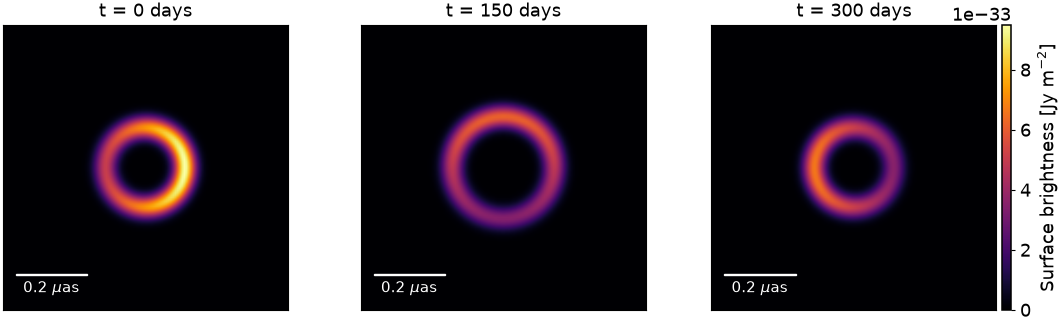

In [2]:
display_times = (0.0, 150.0, 300.0)
images = system.realize().source.brightness(display_times).detach().cpu().numpy()[..., 0]
vmax = float(images.max())
figure, axes = plt.subplots(1, 3, figsize=(11.4, 3.45))
artist = None
for ax, time, image_values in zip(axes, display_times, images, strict=True):
    artist = ax.imshow(
        image_values, origin="lower",
        extent=(-0.5 * source_fov_uas, 0.5 * source_fov_uas) * 2,
        cmap="inferno", vmin=0.0, vmax=vmax, interpolation="bilinear",
    )
    ax.set_title(f"t = {time:.0f} days")
    mcp.add_scale_bar(ax, 0.2, label=r"0.2 $\mu$as", color="white")
    mcp.hide_image_axes(ax)
mcp.panel_colorbar(figure, axes[-1], artist, label=r"Surface brightness [Jy m$^{-2}$]", size="3%")
figure.tight_layout()
print(source.metadata())


## Supplied images and custom variability

`StaticSource` accepts an already sampled `[y, x, band]` image. The array may
come from a simulation, an observation, or another package. Here we freeze the
callable source at day zero while preserving its physical Jy normalization.

The second example synthesizes a driver from a user-defined PSD. A measured
light curve can instead be supplied directly with `TabulatedDrivingSignal`.


In [3]:
resolved_source = system.realize().source
supplied_image = resolved_source.brightness([0.0])[0]
static_source = mc.StaticSource(supplied_image, resolved_source.geometry)

driver_times = torch.arange(0.0, 3651.0, dtype=torch.float64)
def custom_psd(frequency_per_day):
    return 1.0 / (1.0 + (frequency_per_day / 0.01).square())

psd_driver = mc.driving_signal_from_psd(
    driver_times, custom_psd, standard_deviation=0.2, seed=0,
)
tabulated_driver = mc.TabulatedDrivingSignal(
    driver_times, 1.0 + 0.1 * torch.sin(2.0 * torch.pi * driver_times / 300.0),
)
variable_static_source = mc.ModulatedSource(static_source, psd_driver)
print('Static image shape:', tuple(static_source.brightness([0.0]).shape))
print('Custom PSD samples:', tuple(psd_driver.values.shape))
print('Tabulated amplitudes:', tabulated_driver.amplitudes(
    [0.0, 150.0, 300.0], bands=2, dtype=torch.float32, device='cpu'
).tolist())
print('Driven image shape:', tuple(variable_static_source.brightness([0.0]).shape))


Static image shape: (1, 128, 128, 2)
Custom PSD samples: (3651, 1)
Tabulated amplitudes: [[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]
Driven image shape: (1, 128, 128, 2)


## Use the custom source in a dynamic light curve

No solver-specific adapter is required. The main curve evaluates the custom
source daily using two bracketing map--source contractions from the 25-day
map sequence. Interpolated daily maps are never materialized. A separate
three-epoch call demonstrates batching two source trajectories without
duplicating its streamed maps.
The plotted magnitude uses the source's physical Jy normalization rather than a relative-
magnitude convention.
Requests inherit the system distances. The shared-map batch also supports daily source evolution while generating maps every 25 days. Each coarse map is calculated once for both trajectories.


Dynamic maps: 147 daily custom-source samples: 3651
Batched light curves: ('centered ring', 'offset ring')


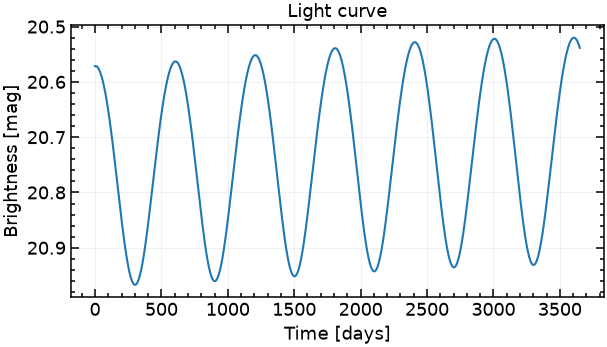

In [4]:
method = mc.production_ipm_config(
    rays=10_000_000 if use_cuda else 262_144,
    cell_chunk_size=524_288 if use_cuda else 65_536,
)
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
requests = (
    mc.LightCurveRequest(source, name='centered ring'),
    mc.LightCurveRequest(
        source, name='offset ring',
        trajectory=mc.LinearTrajectory(
            initial_position_uas=(0.01 * source_fov_uas, -0.01 * source_fov_uas)
        ),
    ),
)
curve = system.light_curve(
    duration_days=3650, map_cadence_days=25, source_cadence_days=1,
    method=method, temporal_batch_size=49, scout_refresh_frames=10,
)
print('Dynamic maps:', len(map_times), 'daily custom-source samples:', len(flux_times))
# A tiny, separate call demonstrates batching multiple trajectories without
# repeating the expensive ten-year production calculation.
batch_demo = system.light_curves(
    requests=requests, duration_days=50, map_cadence_days=25, source_cadence_days=1,
    method=method, temporal_batch_size=49, light_curve_batch_size=2,
)
print('Batched light curves:', tuple(item.metadata['request_name'] for item in batch_demo))
figure, ax = mcp.plot_light_curve(
    curve, bands=("blue",), magnitude=True, normalize=False,
)
ax.set_ylabel("Brightness [mag]")
if ax.get_legend() is not None:
    ax.get_legend().remove()
figure.tight_layout()
